In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import torch


np.set_printoptions(legacy='1.25')
pd.set_option('display.max_colwidth', None)

ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data"
DATA = DATA_PATH / "prb_articles_labeled_Jan2016-Jun2026_duplicate-free.json"
DATA_SAMPLE = ROOT / "data" / "prb_articles_labeled_Jan2016-Jun2026_duplicate-free_sample.json"

#CLEANED_DATA is output of prep_data() from preprocessing.py
CLEANED_DATA  = ROOT / "data" / "cleaned_data.json"
CLEANED_DATA_SAMPLE  = ROOT / "data" / "cleaned_data_sample.json"

MODULE_PATH = str(ROOT / "src")
if MODULE_PATH not in sys.path:
    sys.path.append(MODULE_PATH)


data_to_load = CLEANED_DATA if CLEANED_DATA.exists() else CLEANED_DATA_SAMPLE
df = pd.read_json(data_to_load)

print(f"Loaded data from {data_to_load.name}")
df.info()

Loaded data from cleaned_data.json
<class 'pandas.DataFrame'>
RangeIndex: 50398 entries, 0 to 50397
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   doi          50398 non-null  str           
 1   title        50398 non-null  str           
 2   abstract     50398 non-null  str           
 3   physh        50398 non-null  object        
 4   date         50398 non-null  datetime64[us]
 5   articleType  50398 non-null  str           
 6   physh_names  50398 non-null  object        
dtypes: datetime64[us](1), object(2), str(4)
memory usage: 2.7+ MB


## PhysBERT Tokenizer

In [57]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

# Load PhysBERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("thellert/physbert_uncased")
model_physbert = AutoModel.from_pretrained("thellert/physbert_uncased")

2026-08-10 15:42:33,368 - INFO - HTTP Request: HEAD https://huggingface.co/thellert/physbert_uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-10 15:42:33,381 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/thellert/physbert_uncased/98d5271a02f89a71a4319fae427a5795601fcfc5/config.json "HTTP/1.1 200 OK"
2026-08-10 15:42:33,481 - INFO - HTTP Request: HEAD https://huggingface.co/thellert/physbert_uncased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"


2026-08-10 15:42:33,493 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/thellert/physbert_uncased/98d5271a02f89a71a4319fae427a5795601fcfc5/tokenizer_config.json "HTTP/1.1 200 OK"
2026-08-10 15:42:33,595 - INFO - HTTP Request: GET https://huggingface.co/api/models/thellert/physbert_uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-08-10 15:42:33,677 - INFO - HTTP Request: GET https://huggingface.co/api/models/thellert/physbert_uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-08-10 15:42:34,019 - INFO - HTTP Request: HEAD https://huggingface.co/thellert/physbert_uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-10 15:42:34,032 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/thellert/physbert_uncased/98d5271a02f89a71a4319fae427a5795601fcfc5/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
encodings = tokenizer(
    df["title"].tolist(),
    df["abstract"].tolist(),
    truncation=False,  # No truncation to see token length distribution
)

# Calculate the length of each sample's input_ids
lengths = [len(ids) for ids in encodings["input_ids"]]
s = pd.Series(lengths)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (588 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
# 97% of the data have token length < 384. Can set max_length=384 instead of 512 in tokenizer
s[s<384].shape[0]  / s.shape[0]

0.9737886424064447

In [ ]:
s.describe()

count    50398.000000
mean       221.114826
std         70.205338
min         44.000000
25%        172.000000
50%        211.000000
75%        259.000000
max        806.000000
dtype: float64

In [ ]:
print(f"Memory consumption of titles + abstract text of the entire dataset: {(df["title"].memory_usage(deep=True) + df["abstract"].memory_usage(
    deep=True)) / (1024**2):.2f} MB")

Memory consumption of titles + abstract text of the entire dataset: 90.46 MB


In [ ]:
num_papers = len(df)
dimensions = 768  # PhysBERT output vector size
float32_bytes = 4  # Standard float size in NumPy/PyTorch

total_bytes = num_papers * dimensions * float32_bytes
mb_used = total_bytes / (1024**2)

print(
    f"Target Embeddings Array ({num_papers} x {dimensions}): {mb_used:.2f} MB"
)

Target Embeddings Array (50398 x 768): 147.65 MB


## napkinXC for a single batch of 25

In [19]:
from torch.utils.data import DataLoader

batch_size = 25
dataset_loader = DataLoader(df['abstract'].to_list(), batch_size=batch_size)


In [20]:
# Get one batch
first_batch = next(iter(dataset_loader))

# Tokenize the input text and pass it through the model
inputs = tokenizer(first_batch, padding=True, 
    truncation=True,return_tensors='pt')
outputs = model_physbert(**inputs)



In [ ]:

# Extract the token embeddings
token_embeddings = outputs.last_hidden_state
# Drop CLS and SEP tokens, then take the mean for the sentence embedding
token_embeddings = token_embeddings[:, 1:-1, :] #careful here
sentence_embedding = token_embeddings.mean(dim=1)

In [24]:
for name, _ in model_physbert.named_modules(): print(name)


bert
bert.embeddings
bert.embeddings.word_embeddings
bert.embeddings.position_embeddings
bert.embeddings.token_type_embeddings
bert.embeddings.LayerNorm
bert.embeddings.dropout
bert.encoder
bert.encoder.layer
bert.encoder.layer.0
bert.encoder.layer.0.attention
bert.encoder.layer.0.attention.self
bert.encoder.layer.0.attention.self.query
bert.encoder.layer.0.attention.self.key
bert.encoder.layer.0.attention.self.value
bert.encoder.layer.0.attention.self.dropout
bert.encoder.layer.0.attention.output
bert.encoder.layer.0.attention.output.dense
bert.encoder.layer.0.attention.output.LayerNorm
bert.encoder.layer.0.attention.output.dropout
bert.encoder.layer.0.intermediate
bert.encoder.layer.0.intermediate.dense
bert.encoder.layer.0.intermediate.intermediate_act_fn
bert.encoder.layer.0.output
bert.encoder.layer.0.output.dense
bert.encoder.layer.0.output.LayerNorm
bert.encoder.layer.0.output.dropout
bert.encoder.layer.1
bert.encoder.layer.1.attention
bert.encoder.layer.1.attention.self
bert.e

In [66]:
from sklearn.preprocessing import MultiLabelBinarizer
from napkinxc.models import PLT

In [64]:
mlb = MultiLabelBinarizer()
y_train_binarized_physbert = mlb.fit_transform(df['physh_names'].head(25))


In [76]:
# Load Probabilistic Label Tree if already exists, train if doesn't
napkinxc_physbert_path = Path("physh_plt_model_physbert")

if (napkinxc_physbert_path / "weights.bin").exists():
    napkinxc_physbert_model = PLT(str(napkinxc_physbert_path))

else:
    napkinxc_physbert_model = PLT(str(napkinxc_physbert_path))
    napkinxc_physbert_model.fit(sentence_embedding.detach().numpy(), y_train_binarized_physbert)



In [79]:

# Sample text to embed
prediction_text = "In this study, we propose that the signatures of spin fractionalization in quantum magnets can be identified through a detailed analysis of the temperature dependence of the asymmetric Fano lineshape of optical phonons overlapping with a continuum of spin excitations. We focus on the hyperhoneycomb magnet 𝛽−Li2⁢IrO3, a promising candidate for being in proximity to a three-dimensional Kitaev quantum spin liquid. The Raman response in 𝛽−Li2⁢IrO3 notably displays a distinctive asymmetric Fano lineshape in the 24 meV Raman-active optical phonon. This asymmetry arises from the interaction between the discrete phonon mode and the spin excitation continuum, which could be fractionalized if the material is indeed near a quantum spin-liquid phase. Our theoretical model considers the coupling of this optical phonon to Majorana fermions in the Kitaev model on the hyperhoneycomb lattice. Our findings reveal that the temperature-dependent Fano lineshape is consistent with the fractionalization of spins into Majorana fermions and ℤ2 fluxes."

# Tokenize the input text and pass it through the model
inputs = tokenizer(sample_text, return_tensors="pt")
outputs = model_physhbert(**inputs)

# Extract the token embeddings
token_embeddings = outputs.last_hidden_state
# Drop CLS and SEP tokens, then take the mean for the sentence embedding
token_embeddings = token_embeddings[:, 1:-1, :]
sentence_embedding_prediction = token_embeddings.mean(dim=1)


In [ ]:
#Invoke model to make predictions on a given article
napkinxc_physbert_model.predict(sentence_embedding_prediction.detach().numpy(), top_k=5)

[[75, 24, 95, 86, 22]]

In [96]:
[[mlb.classes_[idx] for idx in sample] for sample in [[75, 24, 95, 86, 22]]]

[['Quantum transport',
  'First-principles calculations',
  'Topological materials',
  'Superconductivity',
  'Excitons']]

In [ ]:
print(precision_at_k(y_test_binarized_preprune, predictions_napkinXC_preprune, k=5)) 


NameError: name 'y_test_binarized_preprune' is not defined

# napkinXC with the physBERT embeddings for the entire dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from napkinxc.models import PLT
from napkinxc.metrics import precision_at_k
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
X_transformed_physbert = np.load(DATA_PATH / "physbert_embeddings.npy")

In [53]:
np.dot(X_transformed_physbert[0],X_transformed_physbert[2])

np.float32(210.74893)

In [10]:
target = 'physh_names'
y = df[target]

In [12]:
# Splitting the dataset into train and test sets for single label
X_train_napkinXC, X_test_napkinXC, y_train_napkinXC, y_test_napkinXC = train_test_split(X_transformed_physbert.squeeze(), y, test_size=0.2, random_state=0)


In [15]:
mlb = MultiLabelBinarizer()
y_train_binarized_napkinXC = mlb.fit_transform(y_train_napkinXC)
y_test_binarized_napkinXC = mlb.transform(y_test_napkinXC)
len(mlb.classes_)

/home/rustycutlery/cppexampl/pys/PhySH-Tank/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['A ≥ 220', 'Accelerator subsystems', 'Accelerators & storage rings', 'Astronomical black holes', 'Beam code development & simulation techniques', 'Beam polarization', 'Beta decay', 'Biomolecular dynamics', 'Biomolecular structure', 'Block copolymers', 'Cancer', 'Carbohydrates', 'Cavity magnonics', 'Cell membrane', 'Chalcogens', 'Charge migration', 'Chemical hydrogen storage', 'Cold working', 'Conformal foams', 'Diversity', 'Efimov states', 'Exclusion processes', 'Fluorescence recovery after photobleaching', 'Fluorescent biomolecules', 'Foams', 'Form factors', 'Fractional Brownian motion', 'Gamma ray spectroscopy', 'Gravitational wave detectors', 'Helicity', 'Hydrogen production', 'Infrastructures & instrumentation', 'Interconnected & interdependent networks', 'Interfacial flows', 'Isotope shift', 'Kelvin, coastal, & edge waves', 'Kelvin-He

2348

In [ ]:
# Load Probabilistic Label Tree if already exists, train if doesn't (took 2m31s)
napkinxc_physbert_model_path = Path("physh_plt_model_napkinXC")

if (napkinxc_physbert_model_path / "weights.bin").exists():
    model_napkinXC_physbert = PLT(str(napkinxc_physbert_model_path))

else:
    model_napkinXC_physbert = PLT(str(napkinxc_physbert_model_path))
    model_napkinXC_physbert.fit(X_train_napkinXC, y_train_binarized_napkinXC)



In [ ]:
#For loading NetworkX PhySH graph
import networkx as nx
from data.preprocessing import concept_hierarchy_graph

graph_hierarchy = concept_hierarchy_graph()
label_naming = nx.get_node_attributes(graph_hierarchy,'label')
labeled_hierarchy = nx.relabel_nodes(graph_hierarchy, label_naming, copy=True)

In [19]:
#Invoke model to make predictions on the test set
prediction_napkinXC_physbert = model_napkinXC_physbert.predict(X_test_napkinXC, top_k=5)

# Assign contiguous integer IDs to NetworkX nodes
for idx, node in enumerate(labeled_hierarchy.nodes()):
    labeled_hierarchy.nodes[node]['napkin_id'] = idx

# Reverse mapping for prediction decoding
id_to_tag = {data['napkin_id']: node for node, data in labeled_hierarchy.nodes(data=True)}

# Predictions DOIs mapped back to names
predicted_tags_napkinXC_physbert = [[id_to_tag[label_id] for label_id in sample] for sample in prediction_napkinXC_physbert]


In [48]:
print(precision_at_k(y_test_binarized_napkinXC, prediction_napkinXC_physbert, k=5)) 


[0.57093254 0.49191468 0.44229497 0.40424107 0.3714881 ]


In [91]:
input_string= "Excitonic Magnetism in Ruthenium Pyrochlores"+"Strong spin-orbit coupling in d4 systems is expected to stabilize a nonmagnetic J=0 singlet ground state, yet many ruthenium pyrochlores exhibit robust long-range magnetic order. Motivated by this apparent contradiction, we develop a microscopic theory of Van Vleck excitonic magnetism on the pyrochlore lattice. Starting from a multi-orbital Hubbard model with spin-orbit coupling, we derive the effective superexchange interactions within the low-energy singlet--triplet manifold of Ru4+ ions. We analyze the resulting excitonic Hamiltonian using both the spectrum of triplon excitations and a variational treatment of the condensed phase. We identify the instability of the nonmagnetic singlet state toward triplon condensation and determine the resulting magnetic phase diagram as a function of the microscopic hopping parameters. The phase diagram reproduces the magnetic orders known from conventional pyrochlore models while also predicting an additional magnetic phase unique to the singlet--triplet description. Finally, we apply the theory to the pyrochlore ruthenates, with particular emphasis on Nd2Ru2O7, and show that it lies in close proximity to the excitonic quantum critical point. Our results establish a microscopic framework for understanding excitonic magnetism in pyrochlore ruthenates and their magnetic excitation spectrum, providing direct connections to spectroscopic probes, including Raman scattering."

In [92]:
inputs = tokenizer(input_string,
                            padding=True,
                            truncation=True,
                            max_length=512,
                            return_tensors='pt').to("cpu")

# Model forward pass
outputs = model_physbert(**inputs)

# Mean pooling using attention mask
token_embeddings = outputs.last_hidden_state
attention_mask = inputs['attention_mask'].unsqueeze(-1)

# Multiply by attention mask to zero out [PAD] token vectors
sum_embeddings = torch.sum(token_embeddings * attention_mask, dim=1)
sum_mask = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
output_embedding = (sum_embeddings / sum_mask).detach().numpy()


In [93]:
output_tags = model_napkinXC_physbert.predict(output_embedding, top_k=5)
[[id_to_tag[label_id] for label_id in sample] for sample in output_tags]

[['Wave chaos',
  'Embedded atom model',
  'Vascular system',
  'Top quark',
  'Energy sources']]

# Linear SVM with PhysBERT

In [69]:
model_linearSVC =  LinearSVC()
model_linearSVC.fit(X_train_napkinXC,y_train_binarized_napkinXC)

ValueError: y should be a 1d array, got an array of shape (40318, 2348) instead.

In [35]:
predictions_linearreg = model_linearreg.predict(X_test_napkinXC)

In [44]:
predictions_linearreg.shape

(10080, 2348)

In [40]:
model_linearreg.score(X_test_napkinXC,y_test_binarized_napkinXC)

0.018291020765900612

In [ ]:
#Precision@5 for linear regression (Check)
sum([y_test_binarized_napkinXC[idx][np.argsort(abstract_entry)[-5:]].mean() 
              for idx, abstract_entry in enumerate(predictions_linearreg)]) / y_test_binarized_napkinXC.shape[0]

np.float64(0.3572420634920597)

In [ ]:
k=5
prob_matrix_multinomialNB = np.array(prediction_probs_multinomialNB_preprune)[:, :, 1].T
sum([y_test_binarized_preprune[idx][[np.argsort(abstract_entry)[-5:]]].mean()  for idx,abstract_entry in enumerate(prob_matrix_multinomialNB)])/y_test_preprune.shape[0]

# PhysBERT with a Linear Classifier head

In [ ]:
import matplotlib.pyplot as plt
import joblib
import torch

from torch.utils.data import DataLoader, TensorDataset
from models.physBERT_classifier import PhysBERTClassifierHead, evaluate_precision_at_k

In [117]:
df_loss = pd.read_csv(DATA_PATH / "losses.csv")

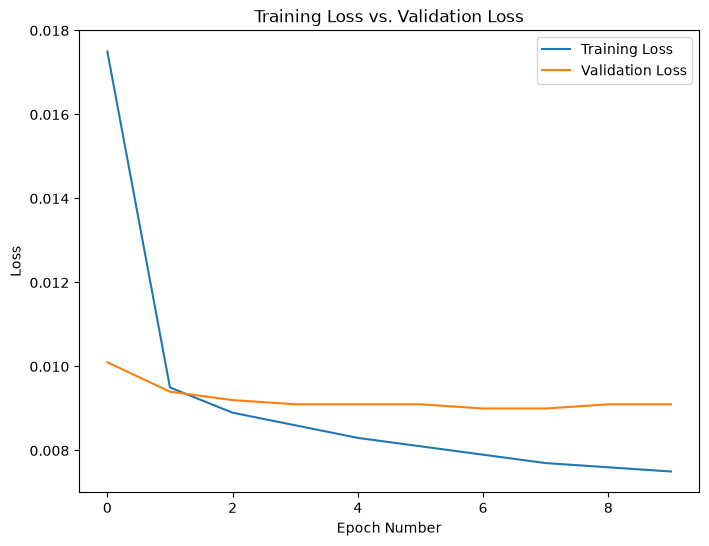

In [118]:
plt.figure(figsize=(8, 6))
plt.plot(df_loss["Train_Loss"],label="Training Loss")
plt.plot(df_loss["Val_Loss"],label="Validation Loss")
plt.xlabel("Epoch Number")
plt.legend()
plt.title("Training Loss vs. Validation Loss")
plt.ylabel("Loss");

In [9]:
# Reload the binarizer
mlb = joblib.load(DATA_PATH / "mlb_binarizer.pkl")

In [ ]:
# Re-create the model architecture & load saved weights
model = PhysBERTClassifierHead(num_classes=len(mlb.classes_))
model.load_state_dict(torch.load(DATA_PATH / "models" / "physbert_classifier_head.pt"))
model.eval()  # Set to evaluation mode

# Predict on a new vector
tolerance_prob = 0.1
with torch.no_grad():
    logits = model(torch.tensor(output_embedding,dtype=torch.float32))
    probs = torch.sigmoid(logits)
    preds = (probs > tolerance_prob).int().cpu().numpy()

# Convert binary matrix back to text tags
predicted_tags = mlb.inverse_transform(preds)
print(predicted_tags)

[('Antiferromagnets', 'Exchange interaction', 'Frustrated magnetism', 'Magnetic order', 'Magnetism', 'Mean field theory', 'Ruthenates', 'Spin-orbit coupling', 'Strongly correlated systems')]


In [120]:
df.head()

,doi,title,abstract,physh,date,articleType,physh_names
0,10.1103/w3nv-g337,"Interface-driven mechanisms for enhancing magnetocrystalline anisotropy and Dzyaloshinskii-Moriya interaction in MTe2/CrI3 (M = Pd, Pt) heterostructures","Modulating the magnetic properties of two-dimensional materials is crucial for advancing spintronic applications. Here, we explore the enhancement effect of perpendicular magnetocrystalline anisotropy (PMA) in MTe2/CrI3 (M = Pd, Pt) van der Waals heterostructures using first-principles calculations. The PMA in PdTe2/CrI3 and PtTe2/CrI3 is enhanced to 3.14 and 2.63 meV, respectively, more than doubling that of monolayer CrI3. This enhancement originates from three distinct mechanisms: reduced (px/y↑)1−(px/y↑)0 interaction gap of I atoms, magnetic proximity effect at the interface, and Rashba effect-induced modulation. Notably, PdTe2/CrI3 exhibits stronger interfacial charge transfer and Rashba splitting, leading to enhanced Dzyaloshinskii-Moriya interaction. Micromagnetic simulations reveal the formation of Néel-type skyrmions under external magnetic fields, with sizes tunable from 9 nm to complete collapse at the field of 2.5 T. For trilayers, PtTe2/CrI3/PtTe2 shows further strengthened PMA (5.84 meV), while PdTe2/CrI3/PdTe2 exhibits spin reorientation phenomenon. Our findings provide insights into interfacial engineering of magnetic properties and demonstrate potential applications in spintronic devices.","[9e019803-f9d8-4802-b1ac-d2c035d9508f, 1f68adf2-72ef-4afa-8536-fd5094c2edd5, dd3e5997-1821-48c1-8e5d-d122961272cf, 7a86b9d8-3162-4279-9ca5-90ebad07be7c, dadd0f02-6a35-463b-997f-67d64338d639, 05d1f0ed-0bf5-4c6d-9e38-a9cf3a67eb5f, 55bba34b-0d31-428f-a430-4f502667434a]",2025-07-01,article,"[Electronic structure, Magnetic interactions, Magnetic anisotropy, 2-dimensional systems, Ferromagnets, Density functional theory, First-principles calculations]"
1,10.1103/gggh-jy6j,Frequency-controlled critical non-Hermitian skin effect in a topolectrical circuit,"One of the most fascinating phenomena in non-Hermitian systems is the extensive accumulation of the bulk eigenstates under open boundary conditions known as the non-Hermitian skin effect (NHSE). Here, we propose a switchable NHSE in a topolectrical setup that can be turned on or off simply by varying the driving frequency without any modification to the physical circuit. Specifically, we consider a coupled system consisting of two non-Hermitian Hatano-Nelson chains where each node on one chain is connected to its neighboring nodes on the other chain via resistive couplings with opposite signs for the two coupling directions. Interestingly, the NHSE is switched on only if the driving frequency is greater than a certain critical frequency. Conversely, the NHSE in the coupled system is switched off when the frequency falls below the critical value, even though the individual uncoupled chains still exhibit the NHSE. This frequency-controlled NHSE may pave the way for many possible applications, including non-Hermitian sensors where the current and voltage localization can be manipulated through the driving frequency.","[491643bd-6b81-4fb8-8b4b-7c30910e26e3, 0026b3bc-1a2f-45df-8025-1243dac91047, bfe403ee-cd34-466b-b8bf-f90b4d4431fc, 18b744bf-c79c-4dc9-a0b6-a8939e4b5c3d, 347c621b-2ddf-4d11-bd25-3380b5623c72, 6d0b28b1-a3eb-40f1-bf96-43308f5d2c56, eac8c4d5-07af-40a1-92d6-f32abca831a1]",2025-07-01,article,"[Skin effect, Topological materials, Topological phases of matter, Topolectrical circuits, 1-dimensional systems, Non-Hermitian systems, Symmetries in condensed matter]"
2,10.1103/ssdc-9bsk,Finite-temperature fermion Monte Carlo simulations of frustrated spin-Peierls systems,"The Abrikosov fermion representation of the spin-1/2 degree of freedom allows for auxiliary-field quantum Monte Carlo simulations of frustrated spin systems. This approach provides a manifold of equivalent actions over which the negative sign problem can be optimized. As a result, we can 

In [12]:
#Load pre-generated physBERT embeddings and create a PyTorch tensor
X = torch.tensor(np.load(DATA_PATH / "physbert_embeddings.npy"),dtype=torch.float32)

y_raw = df['physh_names']
y_binarized = mlb.fit_transform(y_raw)
y = torch.tensor(y_binarized.toarray(), dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [123]:
[evaluate_precision_at_k(model, test_loader, k=k) for k in range(1,6)]

[0.5573412698412699,
 0.48412698412698413,
 0.43220900675607105,
 0.391889880952381,
 0.36253968969223993]

# XGBoost

In [ ]:
# Takes 15m40s on GPU
from xgboost import XGBClassifier

from utils.precision_at_k_custom import precision_at_k_custom

In [13]:
params = {
    'objective':'binary:logistic',
    'device' : "cuda",
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model_xgb = XGBClassifier(**params)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

In [26]:
np.save(DATA_PATH / "y_pred_xgb.npy",y_pred_xgb)

In [4]:
xgb_proba = np.load(DATA_PATH / "xgb_predict_proba.npy")

In [20]:
y_test.shape

torch.Size([10080, 2421])

In [28]:
[precision_at_k_custom(torch.tensor(xgb_proba,dtype=torch.float32),y_test,k) for k in range(1,6)]

[0.5229166746139526,
 0.45843252539634705,
 0.4081680178642273,
 0.3699652850627899,
 0.3405753970146179]